In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

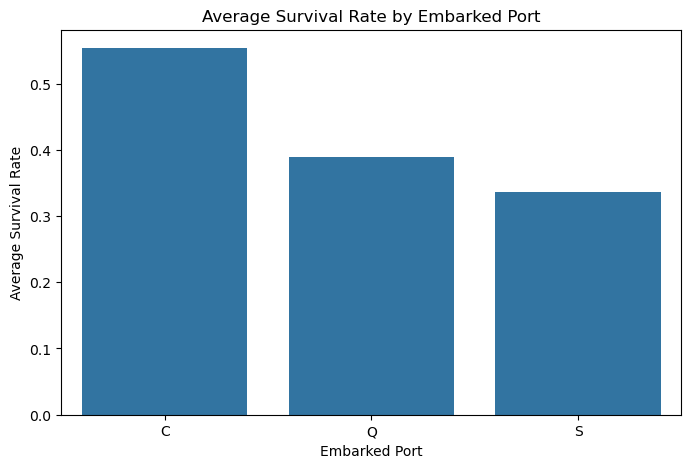

Port with highest survival rate:
Embarked           C
Survived    0.553571
Name: 0, dtype: object


In [3]:
plt.figure(figsize=(8,5))

survival_embarked = df.groupby('Embarked')['Survived'].mean().reset_index()

sns.barplot(
    x='Embarked',
    y='Survived',
    data=survival_embarked
)

plt.title("Average Survival Rate by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Average Survival Rate")

plt.show()


# Highest survival rate port
highest_port = survival_embarked.loc[
    survival_embarked['Survived'].idxmax()
]

print("Port with highest survival rate:")
print(highest_port)

### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

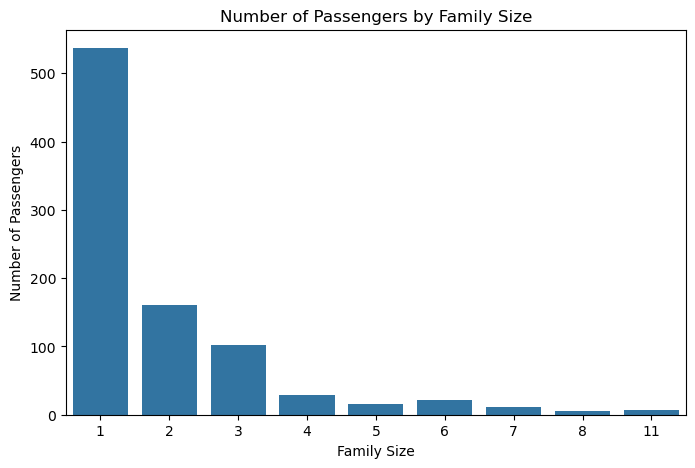

Most common family size:
1


In [13]:
# Create FamilySize column

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


plt.figure(figsize=(8,5))

sns.countplot(x='FamilySize',data=df)

plt.title("Number of Passengers by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.show()


# Most common family size

most_common_family = df['FamilySize'].value_counts().idxmax()

print("Most common family size:")
print(most_common_family)

### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

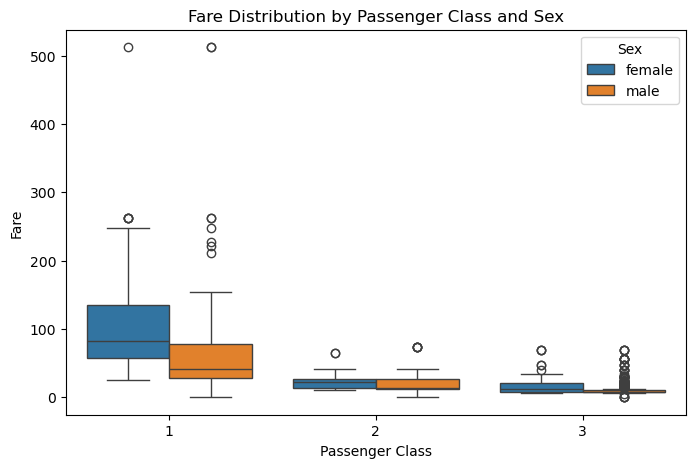

Passenger group with highest fare:
Pclass           1
Sex         female
Fare      512.3292
Name: 258, dtype: object


In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Pclass',y='Fare',hue='Sex',data=df)

plt.title("Fare Distribution by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()


# Highest fare group

highest_fare_group = df.loc[df['Fare'].idxmax(),['Pclass','Sex','Fare']]

print("Passenger group with highest fare:")
print(highest_fare_group)

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

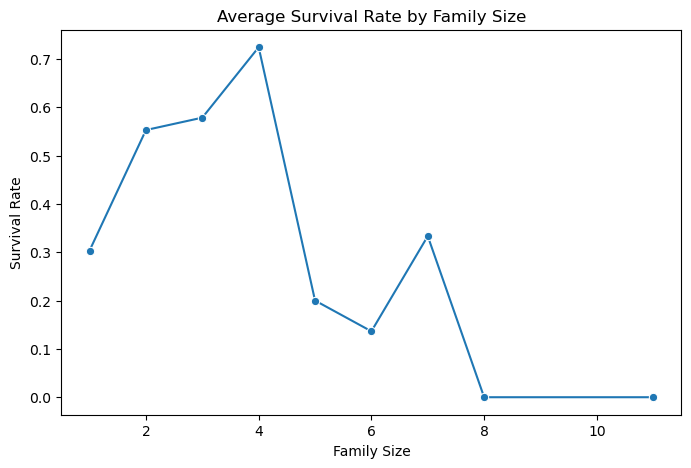

Family size with highest survival rate:
FamilySize    4.000000
Survived      0.724138
Name: 3, dtype: float64


In [12]:
family_survival = df.groupby('FamilySize')['Survived'].mean().reset_index()


plt.figure(figsize=(8,5))

sns.lineplot( x='FamilySize',y='Survived',data=family_survival,marker='o')

plt.title("Average Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()


# Family size with highest survival

highest_survival_family = family_survival.loc[family_survival['Survived'].idxmax()]

print("Family size with highest survival rate:")
print(highest_survival_family)

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

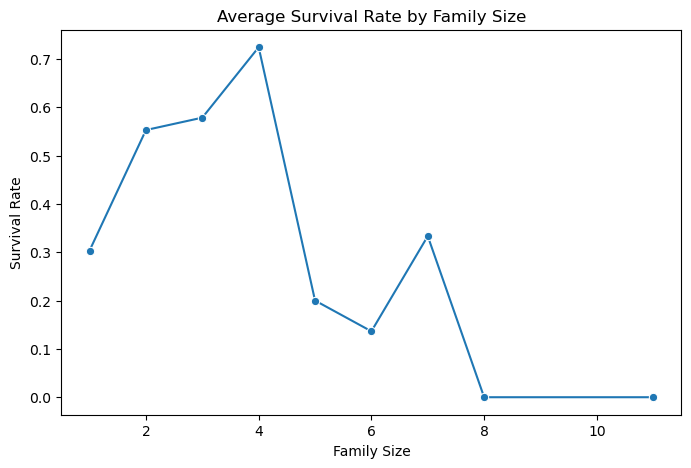

Family size with highest survival rate:
FamilySize    4.000000
Survived      0.724138
Name: 3, dtype: float64


In [10]:
family_survival = df.groupby('FamilySize')['Survived'].mean().reset_index()


plt.figure(figsize=(8,5))

sns.lineplot(x='FamilySize',y='Survived',data=family_survival,marker='o')

plt.title("Average Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()


# Family size with highest survival

highest_survival_family = family_survival.loc[family_survival['Survived'].idxmax()]

print("Family size with highest survival rate:")
print(highest_survival_family)

### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

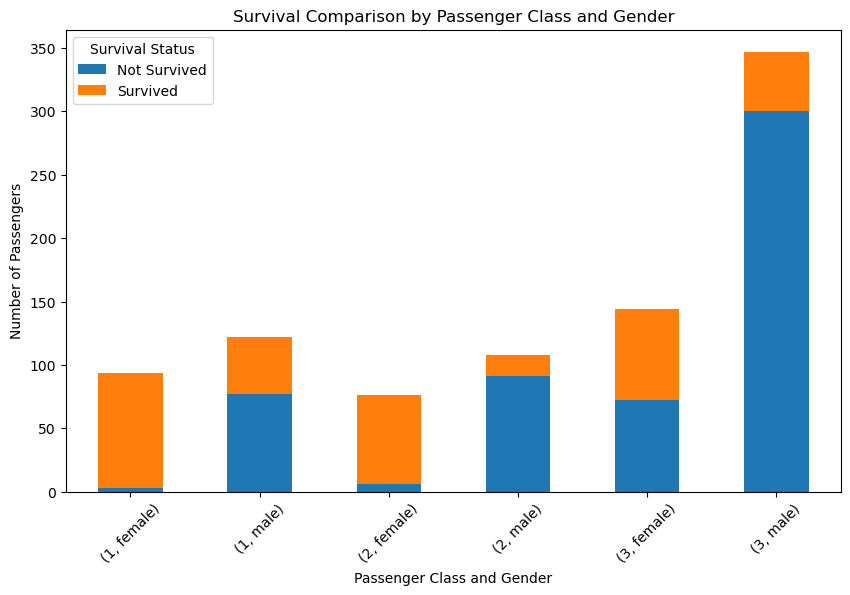

In [9]:
# Create table

survival_table = pd.crosstab([df['Pclass'], df['Sex']],df['Survived'])


# Rename columns

survival_table.columns = ['Not Survived','Survived']


# Stacked bar chart

survival_table.plot(kind='bar',stacked=True,figsize=(10,6))


plt.title("Survival Comparison by Passenger Class and Gender")
plt.xlabel("Passenger Class and Gender")
plt.ylabel("Number of Passengers")

plt.xticks(rotation=45)

plt.legend(title="Survival Status")

plt.show()